In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer

In [3]:
# Load the training data
newsgroups = fetch_20newsgroups(
    subset='train',
    remove=('headers', 'footers', 'quotes')
)

documents = newsgroups.data

print("Number of Documents :", len(documents))

Number of Documents : 11314


In [4]:
vectorizer = CountVectorizer(
    stop_words='english',
    max_features=5000
)

X = vectorizer.fit_transform(documents)

print("Document-Term Matrix Shape:", X.shape)

Document-Term Matrix Shape: (11314, 5000)


In [5]:
word_counts = np.array(X.sum(axis=0)).flatten()

vocab = vectorizer.get_feature_names_out()

print("Vocabulary Size:", len(vocab))
print("First 10 Word Counts:")
print(word_counts[:10])

Vocabulary Size: 5000
First 10 Word Counts:
[1204  693  228  262  211  348   42  170  162   76]


In [6]:
theta_mle = word_counts / np.sum(word_counts)

print("First 10 MLE Probabilities")
print(theta_mle[:10])

First 10 MLE Probabilities
[1.35897937e-03 7.82203240e-04 2.57348252e-04 2.95724746e-04
 2.38160005e-04 3.92794700e-04 4.74062569e-05 1.91882469e-04
 1.82852705e-04 8.57827507e-05]


In [7]:
alpha = 2

K = len(word_counts)

theta_map2 = (word_counts + alpha - 1) / (
    np.sum(word_counts) + K*(alpha-1)
)

print(theta_map2[:10])

[1.35247525e-03 7.78935956e-04 2.57026418e-04 2.95187545e-04
 2.37945854e-04 3.91712750e-04 4.82626024e-05 1.91928024e-04
 1.82948935e-04 8.64237299e-05]


In [8]:
alpha = 10

theta_map10 = (word_counts + alpha - 1) / (
    np.sum(word_counts) + K*(alpha-1)
)

print(theta_map10[:10])

[1.30295749e-03 7.54061135e-04 2.54576195e-04 2.91097675e-04
 2.36315455e-04 3.83475534e-04 5.47822192e-05 1.92274848e-04
 1.83681558e-04 9.13036987e-05]


In [9]:
alpha = 50

theta_map50 = (word_counts + alpha - 1) / (
    np.sum(word_counts) + K*(alpha-1)
)

print(theta_map50[:10])

[1.10790931e-03 6.56080371e-04 2.44924882e-04 2.74987864e-04
 2.29893391e-04 3.51029525e-04 8.04626870e-05 1.93640972e-04
 1.86567329e-04 1.10525669e-04]


In [10]:
comparison = pd.DataFrame({
    "Word": vocab[:10],
    "MLE": theta_mle[:10],
    "MAP α=2": theta_map2[:10],
    "MAP α=10": theta_map10[:10],
    "MAP α=50": theta_map50[:10]
})

comparison

,Word,MLE,MAP α=2,MAP α=10,MAP α=50
0,00,0.001359,0.001352,0.001303,0.001108
1,000,0.000782,0.000779,0.000754,0.000656
2,01,0.000257,0.000257,0.000255,0.000245
3,02,0.000296,0.000295,0.000291,0.000275
4,03,0.000238,0.000238,0.000236,0.000230
5,04,0.000393,0.000392,0.000383,0.000351
6,040,0.000047,0.000048,0.000055,0.000080
7,05,0.000192,0.000192,0.000192,0.000194
8,06,0.000183,0.000183,0.000184,0.000187
9,07,0.000086,0.000086,0.000091,0.000111


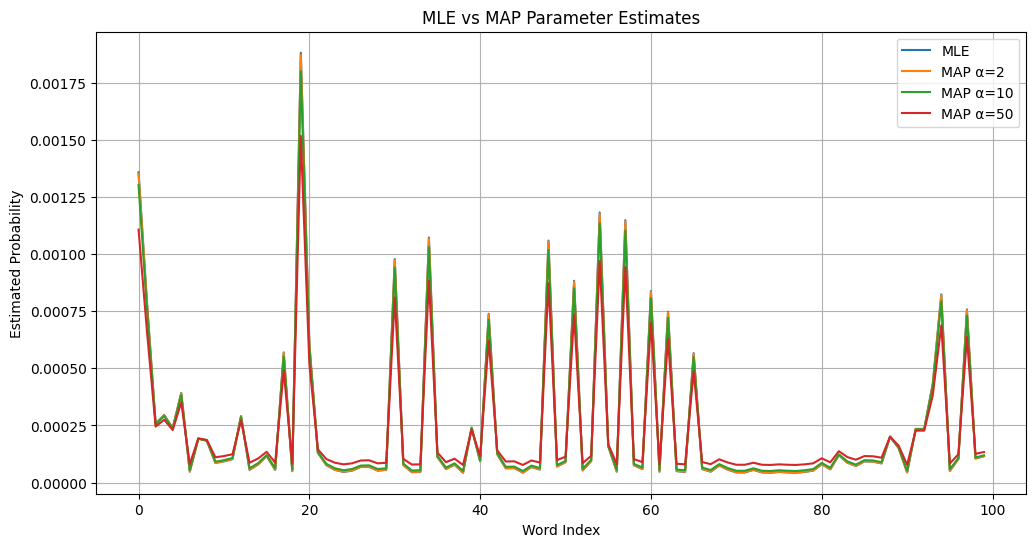

In [11]:
plt.figure(figsize=(12,6))

plt.plot(theta_mle[:100], label='MLE')
plt.plot(theta_map2[:100], label='MAP α=2')
plt.plot(theta_map10[:100], label='MAP α=10')
plt.plot(theta_map50[:100], label='MAP α=50')

plt.xlabel("Word Index")
plt.ylabel("Estimated Probability")
plt.title("MLE vs MAP Parameter Estimates")

plt.legend()

plt.grid(True)

plt.show()